# COMP4131 - Data Modelling and Analysis - Coursework 2
# House Price Prediction using Machine Learning

## 1. Introduction

This notebook explores a housing dataset and aims to understand the relationships between housing features and price.

## Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.ticker import StrMethodFormatter
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, r2_score

from xgboost import XGBRegressor

sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## 2. Load Dataset and Data Overview

The dataset is loaded from a local file. The file should be placed in the same directory as this notebook. This section also provides an overview of the dataset structure, including the number of rows, columns, and data types.

In [2]:
df_original = pd.read_csv("data.csv")
df = df_original.copy()

print("Dataset shape:", df.shape)
display(df.head())
display(df.info())
display(df.describe())

Dataset shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

None

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## 3. Missing Value Analysis

This section examines missing values in the dataset by computing their count and percentage for each feature. The results are sorted to identify columns with incomplete data.

A heatmap is used to visualise the distribution of missing values and detect potential patterns.

If no missing values are found, the dataset is considered complete.

In [3]:
null_counts = df.isnull().sum()
null_percent = (df.isnull().sum() / len(df)) * 100

missing_summary = pd.concat(
    [null_counts, null_percent],
    axis=1,
    keys=["Total", "Percentage"]
)

missing_summary = missing_summary[missing_summary["Total"] > 0].sort_values(
    by="Percentage", ascending=False
)

print("Columns with missing values:")
display(missing_summary)

if not missing_summary.empty:
    plt.figure(figsize=(12, 6))
    sns.heatmap(df[missing_summary.index].isnull(), cbar=False, cmap="viridis")
    plt.title("Heatmap of Missing Values")
    plt.xlabel("Features with Missing Data")
    plt.show()
else:
    print("No missing values detected.")

Columns with missing values:


,Total,Percentage


No missing values detected.


## Exploratory Data Analysis (EDA)
### Target Variable Analysis

The distribution of the target variable (*price*) is examined to understand its statistical properties and potential skewness. 

A histogram with kernel density estimation (KDE) is used to visualise the overall distribution of house prices. In addition, the skewness of the target variable is computed to quantify the degree of asymmetry.

This analysis helps identify whether transformations (e.g., logarithmic scaling) may be required to stabilise variance and improve model performance.

### Relationship Between Key Features and House Price

Several visualisation techniques are applied to explore the relationship between key features and house prices.

First, a regression plot is used to analyse the relationship between *sqft_living* and *price*. The correlation coefficient is computed and displayed in the plot title to quantify the strength of the linear relationship.

Next, categorical variables such as *waterfront* and *view* are analysed using boxplots. These plots illustrate how property attributes influence the distribution of house prices across different categories.

Furthermore, additional features such as *bedrooms*, *bathrooms*, and *sqft_above* are explored to assess their impact on pricing. These analyses provide a comprehensive understanding of both numerical and categorical predictors, supporting the design of effective feature engineering strategies.

Skewness of Price: 24.79


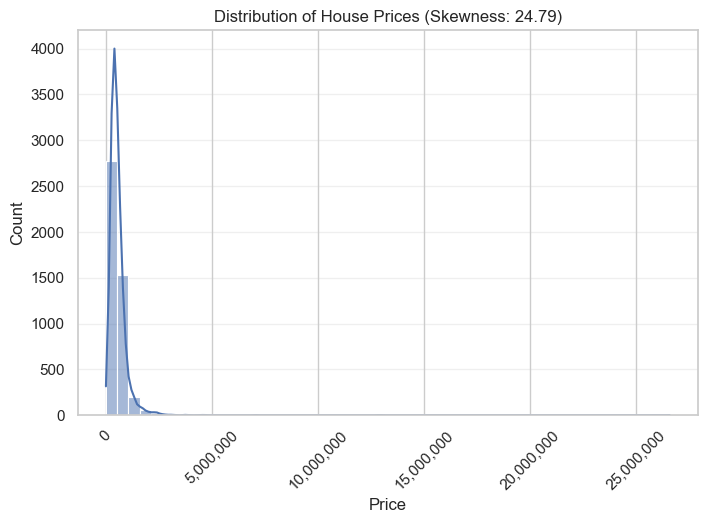

In [4]:
price_skew = df["price"].skew()
print(f"Skewness of Price: {price_skew:.2f}")

plt.figure(figsize=(8, 5))
sns.histplot(df["price"], bins=50, kde=True)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title(f"Distribution of House Prices (Skewness: {price_skew:.2f})")
plt.xlabel("Price")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.grid(axis="y", alpha=0.3)
plt.show()

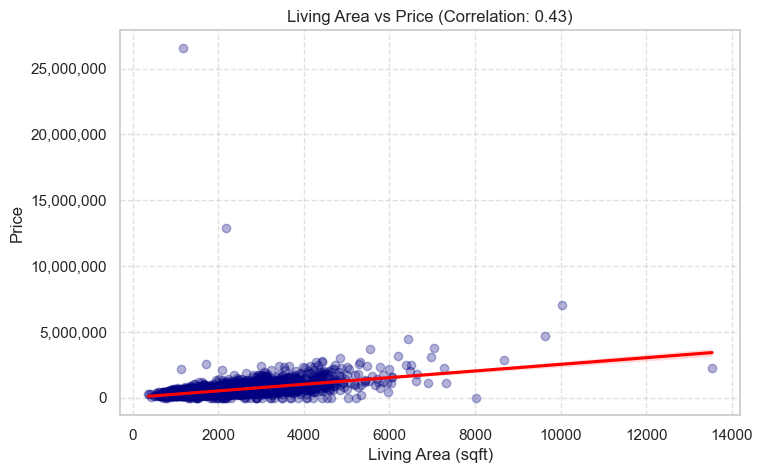

In [5]:
correlation = df["sqft_living"].corr(df["price"])

plt.figure(figsize=(8, 5))
sns.regplot(
    x="sqft_living",
    y="price",
    data=df,
    scatter_kws={"alpha": 0.3, "color": "navy"},
    line_kws={"color": "red"}
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.title(f"Living Area vs Price (Correlation: {correlation:.2f})")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

## Correlation Analysis

This section examines the relationships between numerical features using a correlation matrix.

A heatmap is used to visualise pairwise correlations, helping to identify strong relationships and potential multicollinearity. To improve readability, a triangular mask is applied, while the remaining area is shown in grey to de-emphasise redundant information.

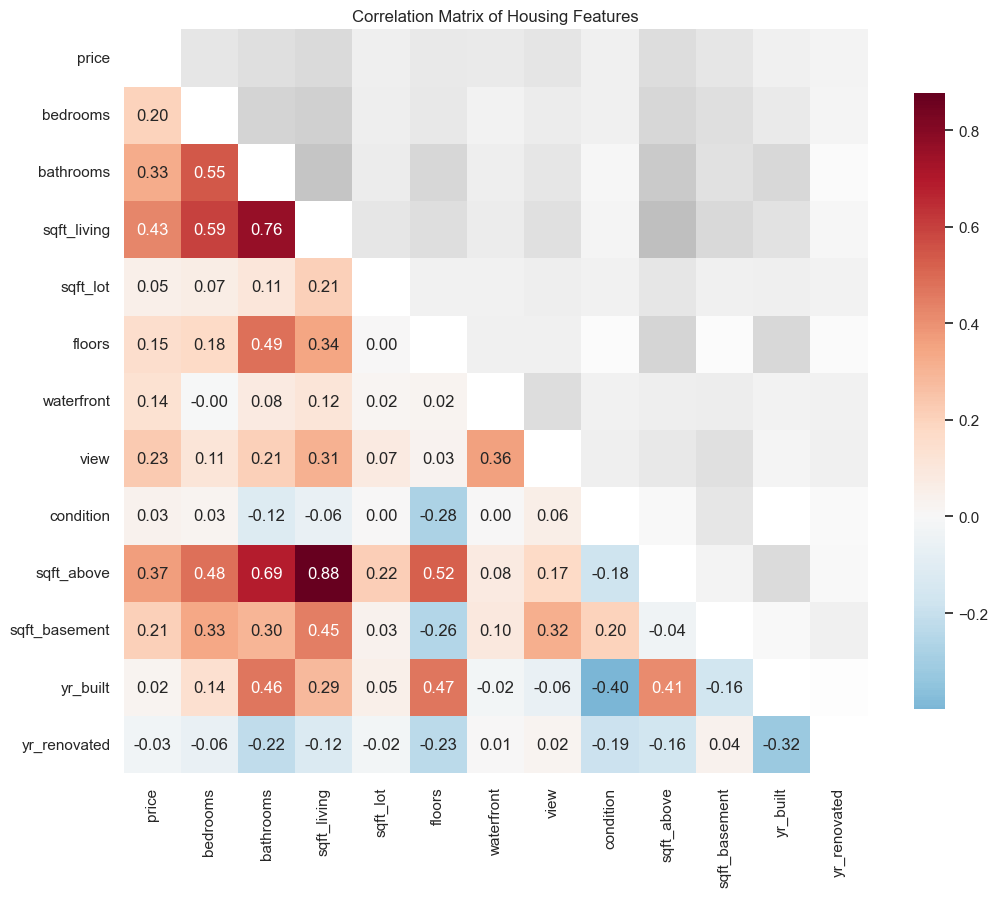

In [6]:
corr = df.corr(numeric_only=True)

mask_lower = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(12, 10))

sns.set_style("white")

sns.heatmap(
    corr,
    mask=mask_lower,
    cmap="Greys",
    cbar=False,
    square=True,
    linewidths=0,     
    alpha=0.25       
)

sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap='RdBu_r',
    center=0,
    square=True,
    linewidths=0,    
    cbar_kws={"shrink": .8}
)

plt.gca().set_facecolor('white')

plt.title("Correlation Matrix of Housing Features")
# plt.savefig("correlation_heatmap.png", bbox_inches='tight') 
plt.show()

### Analysis of Categorical Features

To investigate the influence of categorical variables on house prices, several visualisations are conducted.

A bar plot is used to analyse the average house price across different cities. The cities are sorted by their mean prices, highlighting significant geographical differences in property values. This suggests that location is a critical determinant of house prices.

In addition, boxplots are used to evaluate the impact of binary and ordinal categorical features. The *waterfront* feature is analysed to compare properties with and without waterfront access. The results show that waterfront properties generally have higher prices, indicating a strong positive effect.

Furthermore, the *view* feature is examined using a boxplot, where higher view ratings correspond to higher price distributions. This indicates that visual appeal contributes significantly to property valuation.

These findings confirm that categorical and environmental features provide valuable information and should be incorporated into the predictive modelling process.

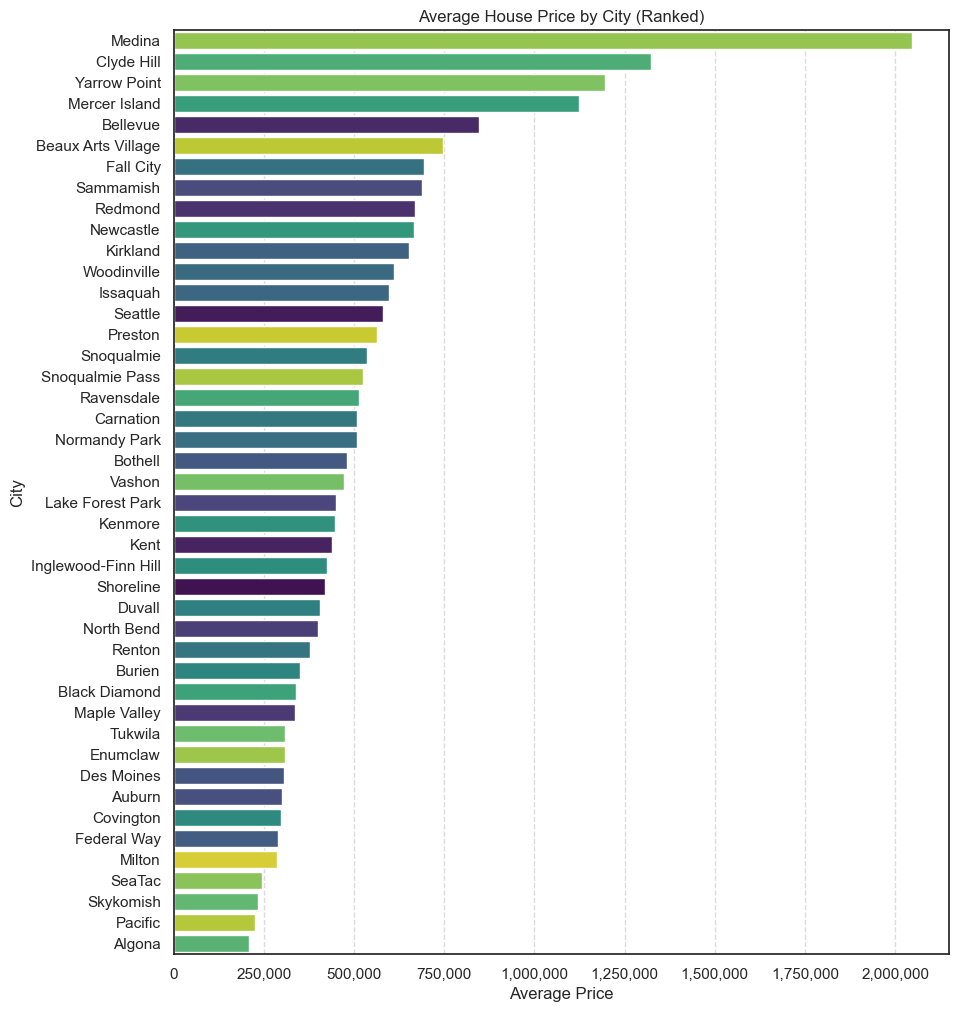

In [7]:
city_order = df.groupby('city')['price'].mean().sort_values(ascending=False).index

plt.figure(figsize=(10, 12))
sns.barplot(
    x="price", 
    y="city", 
    data=df, 
    order=city_order, 
    hue="city",          
    palette="viridis", 
    legend=False,        
    estimator=np.mean, 
    errorbar=None
)

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Average House Price by City (Ranked)")
plt.xlabel("Average Price")
plt.ylabel("City")
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

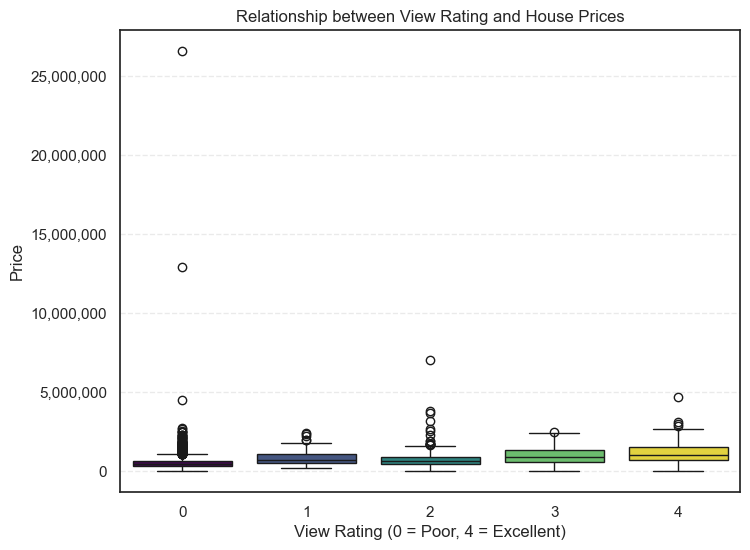

In [8]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="view", 
    y="price", 
    data=df, 
    hue="view", 
    palette="viridis", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Relationship between View Rating and House Prices")
plt.xlabel("View Rating (0 = Poor, 4 = Excellent)")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

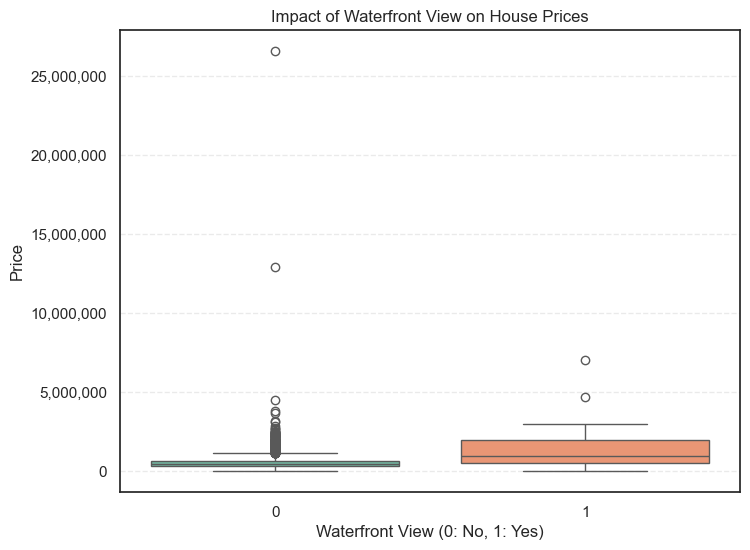

In [9]:
plt.figure(figsize=(8, 6))

sns.boxplot(
    x="waterfront", 
    y="price", 
    data=df, 
    hue="waterfront", 
    palette="Set2", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Impact of Waterfront View on House Prices")
plt.xlabel("Waterfront View (0: No, 1: Yes)")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

## Data Cleaning

To improve data quality and reduce noise, outliers in the target variable (*price*) are removed using the Interquartile Range (IQR) method.

Specifically, the first quartile (\( Q1 \)) and third quartile (\( Q3 \)) are computed, and the interquartile range is defined as:

\[
IQR = Q3 - Q1
\]

Observations with values outside the range:

\[
[Q1 - 1.5 \times IQR,\; Q3 + 1.5 \times IQR]
\]

are considered outliers and removed from the dataset.

After applying this filtering process, the number and percentage of removed observations are calculated to quantify the impact of cleaning. A visual comparison using boxplots is also performed to illustrate the distribution of the target variable before and after outlier removal.

This process reduces the influence of extreme values and improves the robustness of subsequent modelling steps.

Original data size: 4600
After removing outliers: 4360
Number of removed outliers: 240
Percentage removed: 5.22%


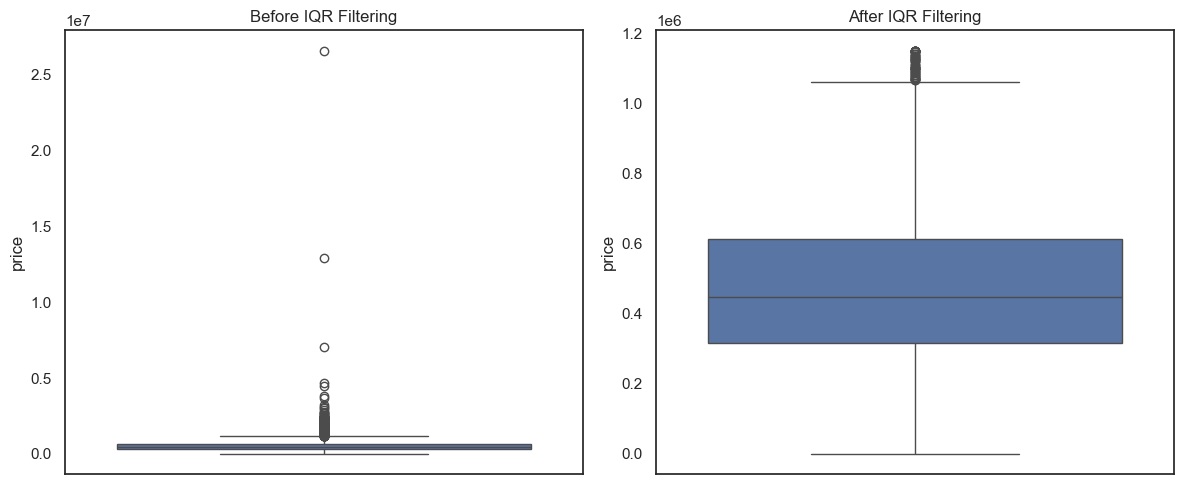

In [10]:
original_size = df.shape[0]

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[
    (df["price"] >= lower_bound) &
    (df["price"] <= upper_bound)
].copy()

removed = original_size - df_cleaned.shape[0]
removed_pct = removed / original_size * 100

print("Original data size:", original_size)
print("After removing outliers:", df_cleaned.shape[0])
print("Number of removed outliers:", removed)
print(f"Percentage removed: {removed_pct:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["price"])
plt.title("Before IQR Filtering")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned["price"])
plt.title("After IQR Filtering")

plt.tight_layout()
plt.show()

### Log Transformation Analysis

The distribution of the target variable (*price*) is further examined using a logarithmic transformation.

The original price distribution exhibits strong positive skewness, indicating the presence of a long tail of high-value properties. Such skewness can negatively impact model performance and lead to biased predictions.

To mitigate this issue, a log transformation is applied using the function \( \log(1 + price) \). This transformation reduces the effect of extreme values and stabilises variance.

Histograms with kernel density estimation (KDE) are used to compare the distributions before and after transformation. The transformed distribution appears more symmetric and closer to a normal distribution.

Furthermore, skewness values are calculated for both the original and transformed variables, demonstrating a clear reduction in skewness after transformation.

Despite these improvements, the original price variable is used for model training in order to preserve interpretability in terms of actual house prices.

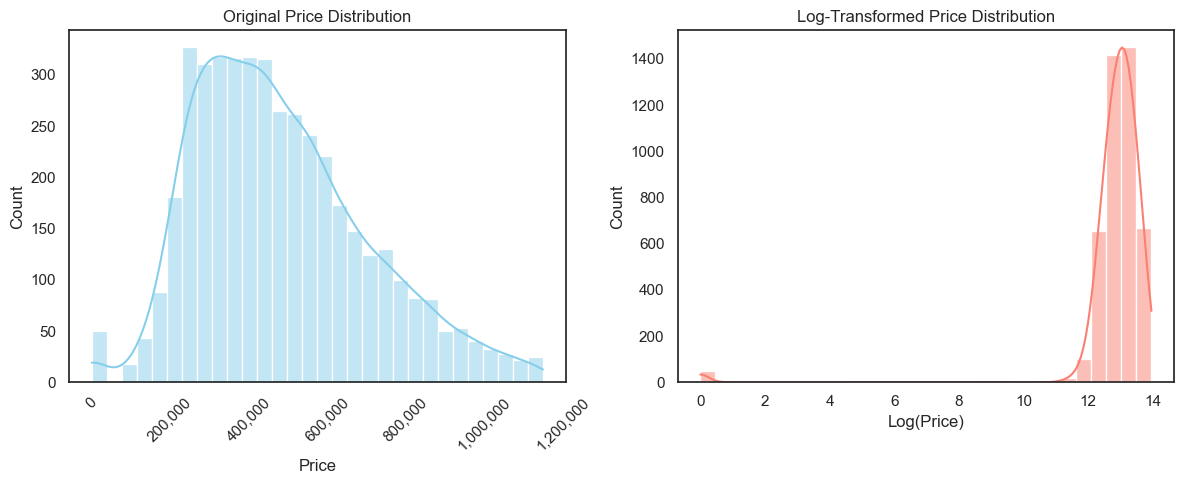

Skewness before: 0.6261498827573944
Skewness after: -7.887665423076715


In [11]:
df_log = df_cleaned.copy()
df_log["log_price"] = np.log1p(df_log["price"])

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_log["price"], bins=30, kde=True, color="skyblue")
plt.title("Original Price Distribution")
plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))
plt.xlabel("Price")
plt.xticks(rotation=45)

plt.subplot(1, 2, 2)
sns.histplot(df_log["log_price"], bins=30, kde=True, color="salmon")
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()

print("Skewness before:", df_log["price"].skew())
print("Skewness after:", df_log["log_price"].skew())

### Feature Engineering

New features are created to enhance the representational power of the dataset. 
These include temporal features, renovation indicators, ratio-based features, 
and composite size features to better capture the relationships between property characteristics and house prices.

In [12]:
df_fe = df_cleaned.copy()

df_fe["date"] = pd.to_datetime(df_fe["date"])

df_fe["year"] = df_fe["date"].dt.year
df_fe["month"] = df_fe["date"].dt.month

print(df_fe[["year", "month"]].head())

   year  month
0  2014      5
2  2014      5
3  2014      5
4  2014      5
5  2014      5


In [13]:
df_fe["house_age"] = df_fe["year"] - df_fe["yr_built"]

df_fe["is_renovated"] = (df_fe["yr_renovated"] > 0).astype(int)

df_fe["year_since_renovation"] = np.where(
    df_fe["yr_renovated"] == 0,
    0,
    df_fe["year"] - df_fe["yr_renovated"]
)

df_fe[["house_age", "is_renovated", "year_since_renovation"]].head()

,house_age,is_renovated,year_since_renovation
0,59,1,9
2,48,0,0
3,51,0,0
4,38,1,22
5,76,1,20


In [14]:
season_map = {
    12: "winter", 1: "winter", 2: "winter",
    3: "spring", 4: "spring", 5: "spring",
    6: "summer", 7: "summer", 8: "summer",
    9: "autumn", 10: "autumn", 11: "autumn"
}

df_fe["season"] = df_fe["month"].map(season_map)

df_fe["season"].value_counts()

season
summer    2681
spring    1679
Name: count, dtype: int64

In [15]:
df_fe["above_ratio"] = df_fe["sqft_above"] / (df_fe["sqft_living"] + 1e-6)
df_fe["room_density"] = df_fe["bedrooms"] / (df_fe["sqft_living"] + 1e-6)
df_fe["basement_ratio"] = df_fe["sqft_basement"] / (df_fe["sqft_living"] + 1e-6)
df_fe["bathroom_density"] = df_fe["bathrooms"] / (df_fe["sqft_living"] + 1e-6)
df_fe["bath_bed_ratio"] = df_fe["bathrooms"] / (df_fe["bedrooms"] + 1e-6)

df_fe[[
    "above_ratio",
    "room_density",
    "basement_ratio",
    "bathroom_density",
    "bath_bed_ratio"
]].head()

,above_ratio,room_density,basement_ratio,bathroom_density,bath_bed_ratio
0,1.000000,0.002239,0.000000,0.001119,0.500000
2,1.000000,0.001554,0.000000,0.001036,0.666666
3,0.500000,0.001500,0.500000,0.001125,0.750000
4,0.587629,0.002062,0.412371,0.001289,0.625000
5,1.000000,0.002273,0.000000,0.001136,0.500000


In [16]:
df_fe["total_sqft"] = df_fe["sqft_living"] + df_fe["sqft_lot"]

df_fe["log_total_sqft"] = np.log1p(df_fe["total_sqft"])

df_fe[["total_sqft", "log_total_sqft"]].head()

,total_sqft,log_total_sqft
0,9252,9.132703
2,13877,9.538060
3,10030,9.213436
4,12440,9.428753
5,7260,8.890273


### Feature Engineering Validation and Visualisation

To assess the effectiveness of the engineered features, several visualisations are conducted.

A regression plot is used to examine the relationship between *house_age* and *price*. The results show a general negative trend, indicating that older properties tend to have lower values due to depreciation effects.

The influence of renovation is analysed using a bar plot comparing *is_renovated* categories. Properties that have undergone renovation exhibit higher average prices, highlighting the importance of property condition and recent improvements.

Additionally, the relationship between *log_total_sqft* and *price* is explored. The logarithmic transformation reduces skewness and reveals a more linear relationship compared to the raw feature, suggesting improved modelling suitability.

The feature *year_since_renovation* is also analysed to capture renovation recency. The results indicate that properties with more recent renovations tend to achieve higher prices, although variability exists.

These findings demonstrate that the engineered features capture meaningful structural and temporal relationships, enhancing the predictive capability of the dataset.

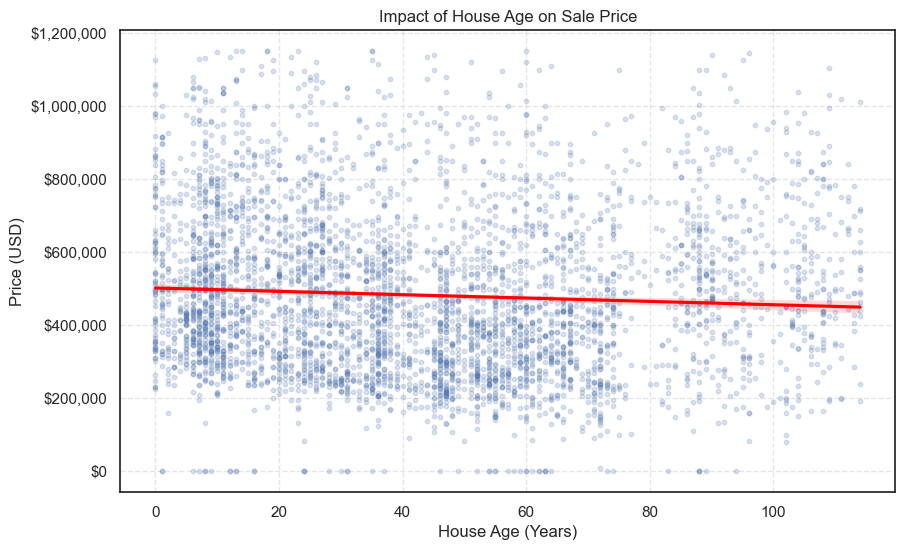

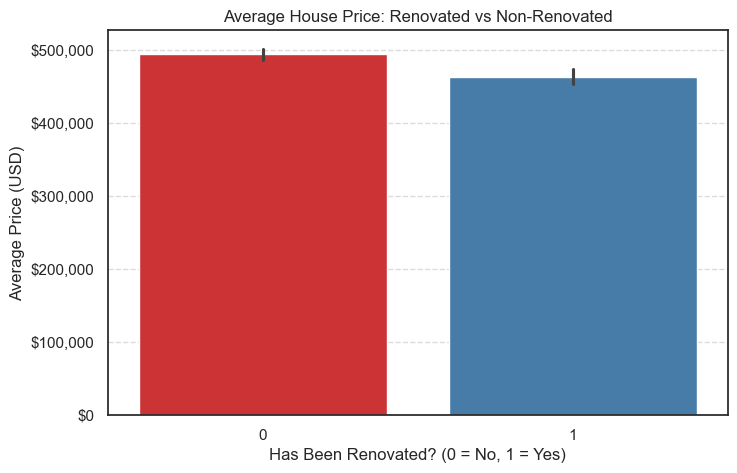

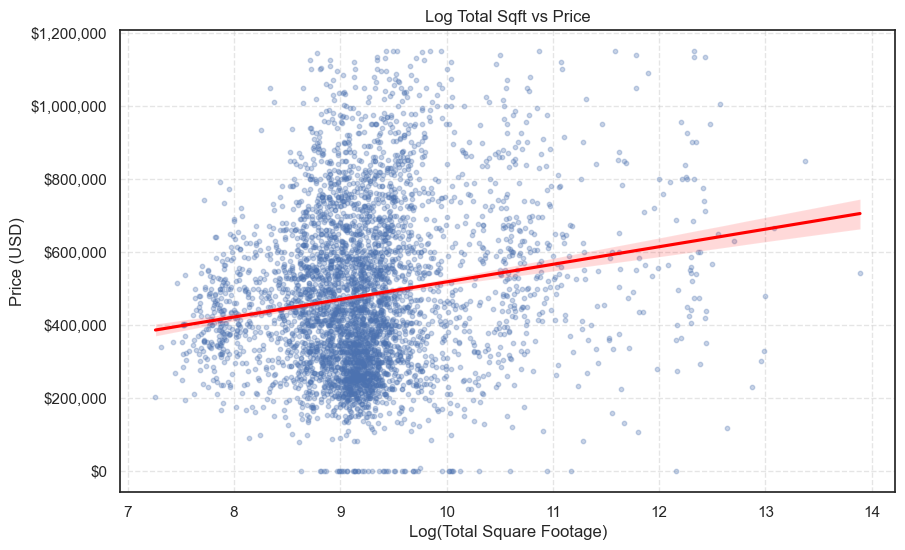

In [17]:
# House age vs price
plt.figure(figsize=(10, 6))
sns.regplot(
    x="house_age",
    y="price",
    data=df_fe,
    scatter_kws={"alpha": 0.2, "s": 10},
    line_kws={"color": "red"}
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Impact of House Age on Sale Price")
plt.xlabel("House Age (Years)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


# Renovated vs non-renovated
plt.figure(figsize=(8, 5))
sns.barplot(
    x="is_renovated",
    y="price",
    data=df_fe,
    hue="is_renovated",
    palette="Set1",
    legend=False
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Average House Price: Renovated vs Non-Renovated")
plt.xlabel("Has Been Renovated? (0 = No, 1 = Yes)")
plt.ylabel("Average Price (USD)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()


# Log total sqft vs price
plt.figure(figsize=(10, 6))
sns.regplot(
    x="log_total_sqft",
    y="price",
    data=df_fe,
    scatter_kws={"alpha": 0.3, "s": 10},
    line_kws={"color": "red"}
)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.title("Log Total Sqft vs Price")
plt.xlabel("Log(Total Square Footage)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

### Build Modelling Dataset

Irrelevant features are removed, and categorical variables are converted into numerical format using one-hot encoding. This ensures compatibility with machine learning models.

In [18]:
df_model = df_fe.copy()

df_model = df_model.drop(
    columns=["street", "country", "date"],
    errors="ignore"
)

print("Remaining columns:", df_model.columns.tolist())

Remaining columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'statezip', 'year', 'month', 'house_age', 'is_renovated', 'year_since_renovation', 'season', 'above_ratio', 'room_density', 'basement_ratio', 'bathroom_density', 'bath_bed_ratio', 'total_sqft', 'log_total_sqft']


In [19]:
df_model = pd.get_dummies(df_model, drop_first=True)

print("Shape after encoding:", df_model.shape)

df_model = df_model.apply(
    lambda col: col.astype(int) if col.dtype == 'bool' else col
)

non_numeric_cols = df_model.select_dtypes(exclude=[np.number]).columns.tolist()

print("Non-numeric columns:", non_numeric_cols)

Shape after encoding: (4360, 145)
Non-numeric columns: []


### Feature Selection

Feature selection is performed in two stages:

1. **Correlation-based filtering:**  
   Features with an absolute correlation greater than 0.2 with the target variable (price) are selected.

2. **Collinearity removal:**  
   Highly correlated features (correlation > 0.8) are removed to reduce redundancy and multicollinearity.

In addition, several domain-relevant features (e.g., waterfront, view, renovation status, and house age) are retained even if their correlation is relatively lower, as they carry important real-world meaning.

In [20]:
corr = df_model.corr(numeric_only=True)

corr_price = corr["price"].abs().sort_values(ascending=False)

selected_features = [
    f for f in corr_price.index
    if f != "price" and corr_price[f] > 0.2
]

print("Selected features (corr > 0.2):")
print(selected_features)
      

important_features = ["waterfront", "view", "is_renovated", "house_age"]
important_features = [f for f in important_features if f in df_model.columns]

selected_features = list(set(selected_features + important_features))

print("After adding important features:")
print(selected_features)

Selected features (corr > 0.2):
['sqft_living', 'sqft_above', 'room_density', 'bathrooms', 'bedrooms', 'floors', 'bathroom_density', 'bath_bed_ratio', 'sqft_basement', 'city_Bellevue']
After adding important features:
['bathroom_density', 'bath_bed_ratio', 'house_age', 'sqft_above', 'room_density', 'is_renovated', 'floors', 'sqft_basement', 'city_Bellevue', 'bedrooms', 'waterfront', 'view', 'sqft_living', 'bathrooms']


In [21]:
corr_selected = df_model[selected_features].corr().abs()

upper = corr_selected.where(
    np.triu(np.ones(corr_selected.shape), k=1).astype(bool)
)

to_drop = [
    col for col in upper.columns
    if any(upper[col] > 0.8)
]

print("Highly correlated features to drop:")
print(to_drop)

final_features = [
    f for f in selected_features if f not in to_drop
]

print("Final selected features:")
print(final_features)

Highly correlated features to drop:
['sqft_living']
Final selected features:
['bathroom_density', 'bath_bed_ratio', 'house_age', 'sqft_above', 'room_density', 'is_renovated', 'floors', 'sqft_basement', 'city_Bellevue', 'bedrooms', 'waterfront', 'view', 'bathrooms']


## Triangular Correlation Heatmap

A triangular correlation heatmap is used to visualise the relationships between the selected features and the target variable (*price*).

To improve clarity, only the upper triangle of the correlation matrix is displayed with colour-coded values, while the lower triangle is masked and shown in a light grey background. This avoids duplication and enhances interpretability.

The heatmap shows that the selected features maintain meaningful correlations with the target variable, particularly for features related to property size and structure. At the same time, the correlations between features are generally low, confirming that highly collinear variables have been successfully removed during the feature selection process.

This visualisation provides strong evidence that the final feature set is both informative and well-conditioned for model training.

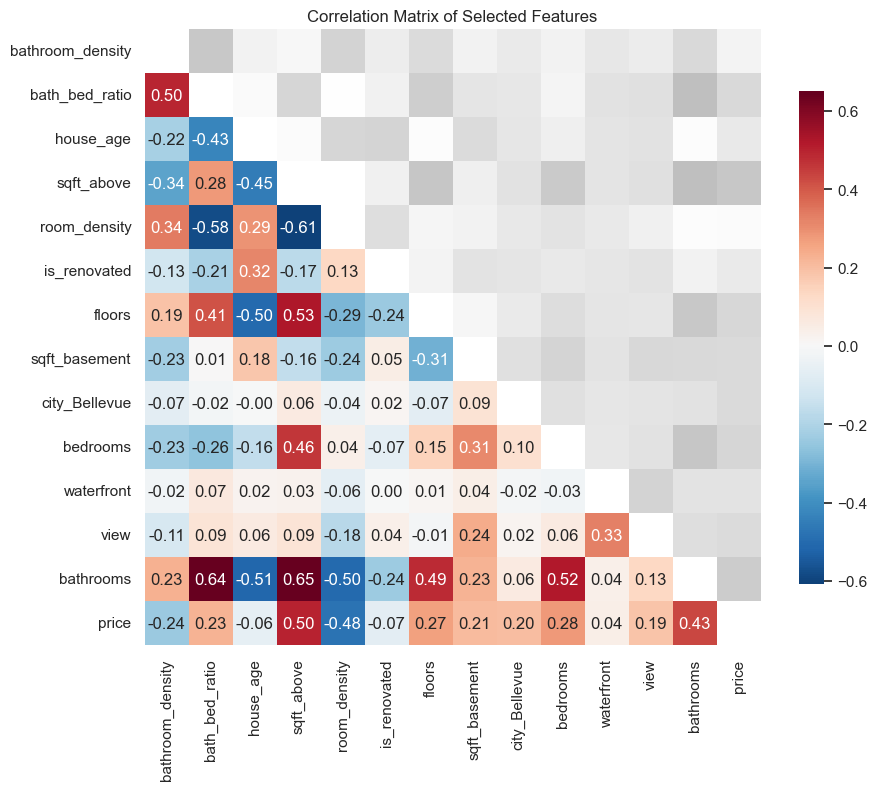

In [22]:
corr = df_model[final_features + ["price"]].corr()

mask_lower = np.tril(np.ones_like(corr, dtype=bool))

plt.figure(figsize=(10, 8))

sns.set_style("white")

sns.heatmap(
    corr,
    mask=mask_lower,
    cmap="Greys",
    cbar=False,
    square=True,
    linewidths=0,
    alpha=0.25
)

sns.heatmap(
    corr,
    mask=np.triu(np.ones_like(corr, dtype=bool)),
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    square=True,
    linewidths=0,
    cbar_kws={"shrink": 0.8}
)

plt.gca().set_facecolor("white")

plt.title("Correlation Matrix of Selected Features")
plt.show()

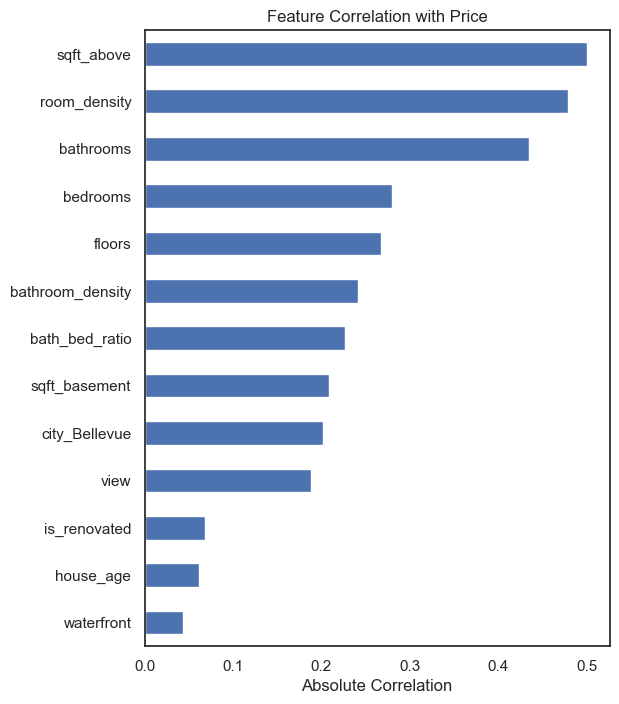

In [23]:
plt.figure(figsize=(6, 8))
corr_price[final_features].sort_values().plot(kind="barh")
plt.title("Feature Correlation with Price")
plt.xlabel("Absolute Correlation")
plt.show()

## 12. Train-Test Split and Feature Scaling

The dataset is split into training and testing sets with a ratio of 80:20. The training set is used for model development, while the test set is used to evaluate the final performance on unseen data. A fixed random state is applied to ensure reproducibility.

To standardise the feature values, all input variables are scaled using the StandardScaler. This transformation ensures that each feature has zero mean and unit variance.

Feature scaling is particularly important for models such as Linear Regression and Multi-Layer Perceptron (MLP), which are sensitive to differences in feature magnitude. In addition, scaling helps improve optimisation efficiency and numerical stability.

The scaler is fitted only on the training data and then applied to the test data. This prevents information from the test set from leaking into the training process, ensuring a fair evaluation of model performance.

In [24]:
X = df_model[final_features]
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Train shape: (3488, 13)
Test shape: (872, 13)
Scaled train shape: (3488, 13)
Scaled test shape: (872, 13)


## Base Models

Four baseline regression models are implemented to capture different types of relationships within the dataset.

**Linear Regression** is used as a fundamental baseline model. It assumes a linear relationship between features and the target variable and serves as a benchmark for evaluating more complex models.

**Random Forest Regressor** is employed as a bagging-based ensemble method. It constructs multiple decision trees and averages their predictions, improving robustness and reducing variance. The model is configured with 200 trees and a maximum depth of 10.

**XGBoost Regressor** is used as a boosting-based ensemble model. It builds trees sequentially to minimise prediction errors and is known for its strong performance on structured datasets. The model is configured with 100 estimators, a learning rate of 0.1, and a maximum depth of 5.

**Multi-Layer Perceptron (MLP)** is implemented to capture complex non-linear interactions. The network consists of two hidden layers (64 and 32 units), and is trained with early stopping to prevent overfitting and improve generalisation.

These models provide a diverse set of learning strategies, including linear, bagging, boosting, and neural network approaches. This diversity is essential for constructing an effective stacking ensemble in later stages.

In [25]:
base_models = {
    "Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        random_state=42
    ),
    "XGBoost": XGBRegressor(
        objective="reg:squarederror",
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        random_state=42
    ),
    "MLP": MLPRegressor(
        hidden_layer_sizes=(64, 32),
        max_iter=2000,
        alpha=0.001,
        learning_rate_init=0.001,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=42
    )
}

In [26]:
# ==============================
# 14.1 Base model evaluation
# ==============================

results = []

for name, model in base_models.items():
    print(f"Training {name}...")

    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)

    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])
display(results_df.sort_values(by="RMSE"))

Training Linear...
Training Random Forest...
Training XGBoost...
Training MLP...


,Model,RMSE,R2
2,XGBoost,164073.182581,0.456684
1,Random Forest,165654.057777,0.446164
3,MLP,166324.887815,0.441669
0,Linear,167003.361519,0.437104


In [27]:
# ==============================
# 15. Stacking ensemble
# ==============================

kf = KFold(n_splits=5, shuffle=True, random_state=42)

train_oof = np.zeros((X_train_scaled.shape[0], len(base_models)))
test_preds = np.zeros((X_test_scaled.shape[0], len(base_models)))

for i, (name, model) in enumerate(base_models.items()):
    print(f"Generating OOF for {name}...")
    fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))

    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
        model_clone = clone(model)

        X_f_train = X_train_scaled.iloc[train_idx]
        X_f_val = X_train_scaled.iloc[val_idx]
        y_f_train = y_train.iloc[train_idx]
        y_f_val = y_train.iloc[val_idx]

        model_clone.fit(X_f_train, y_f_train)

        train_oof[val_idx, i] = model_clone.predict(X_f_val)
        fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

    test_preds[:, i] = fold_test_preds.mean(axis=1)

Generating OOF for Linear...
Generating OOF for Random Forest...
Generating OOF for XGBoost...
Generating OOF for MLP...


In [28]:
# ==============================
# 15.1 Meta learner
# ==============================

X_meta_train = pd.DataFrame(train_oof, columns=base_models.keys(), index=X_train_scaled.index)
X_meta_test = pd.DataFrame(test_preds, columns=base_models.keys(), index=X_test_scaled.index)

# Passthrough
X_meta_train_full = pd.concat([X_meta_train, X_train_scaled], axis=1)
X_meta_test_full = pd.concat([X_meta_test, X_test_scaled], axis=1)

meta_learner = Ridge(alpha=1.0)
meta_learner.fit(X_meta_train_full, y_train)

y_final_pred = meta_learner.predict(X_meta_test_full)

final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_r2 = r2_score(y_test, y_final_pred)

print("Stacking RMSE:", final_rmse)
print("Stacking R2:", final_r2)

Stacking RMSE: 162571.97736081053
Stacking R2: 0.4665806677594746


In [29]:
# ==============================
# 16. Cross-validation for base models
# ==============================

for name, model in base_models.items():
    scores = cross_val_score(
        model,
        X_train_scaled,
        y_train,
        cv=5,
        scoring="neg_root_mean_squared_error"
    )
    print(f"{name} CV RMSE:", -scores.mean())

Linear CV RMSE: 169014.70369218866
Random Forest CV RMSE: 165585.44152706346
XGBoost CV RMSE: 164787.03079459516
MLP CV RMSE: 168759.5341060781


In [30]:
# ==============================
# 17. Ablation study
# ==============================

ablation_results = []

model_names = list(base_models.keys())

for remove_model in model_names:
    print(f"\n--- Removing {remove_model} ---")

    ab_models = {k: v for k, v in base_models.items() if k != remove_model}

    train_oof_ab = np.zeros((X_train_scaled.shape[0], len(ab_models)))
    test_preds_ab = np.zeros((X_test_scaled.shape[0], len(ab_models)))

    for i, (name, model) in enumerate(ab_models.items()):
        fold_test_preds = np.zeros((X_test_scaled.shape[0], 5))

        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train_scaled, y_train)):
            model_clone = clone(model)

            X_f_train = X_train_scaled.iloc[train_idx]
            X_f_val = X_train_scaled.iloc[val_idx]
            y_f_train = y_train.iloc[train_idx]

            model_clone.fit(X_f_train, y_f_train)
            train_oof_ab[val_idx, i] = model_clone.predict(X_f_val)
            fold_test_preds[:, fold] = model_clone.predict(X_test_scaled)

        test_preds_ab[:, i] = fold_test_preds.mean(axis=1)

    X_meta_train_ab = pd.DataFrame(train_oof_ab, columns=ab_models.keys(), index=X_train_scaled.index)
    X_meta_test_ab = pd.DataFrame(test_preds_ab, columns=ab_models.keys(), index=X_test_scaled.index)

    X_meta_train_ab_full = pd.concat([X_meta_train_ab, X_train_scaled], axis=1)
    X_meta_test_ab_full = pd.concat([X_meta_test_ab, X_test_scaled], axis=1)

    meta_ab = Ridge(alpha=1.0)
    meta_ab.fit(X_meta_train_ab_full, y_train)
    y_pred_ab = meta_ab.predict(X_meta_test_ab_full)

    rmse_ab = np.sqrt(mean_squared_error(y_test, y_pred_ab))
    r2_ab = r2_score(y_test, y_pred_ab)

    ablation_results.append([f"Remove {remove_model}", rmse_ab, r2_ab])

ablation_results.append(["Full Stacking", final_rmse, final_r2])

ablation_df = pd.DataFrame(ablation_results, columns=["Experiment", "RMSE", "R2"])
display(ablation_df.sort_values(by="RMSE"))


--- Removing Linear ---

--- Removing Random Forest ---

--- Removing XGBoost ---

--- Removing MLP ---


,Experiment,RMSE,R2
4,Full Stacking,162571.977361,0.466581
3,Remove MLP,162623.972162,0.466239
0,Remove Linear,162675.041369,0.465904
2,Remove XGBoost,162687.049820,0.465825
1,Remove Random Forest,162840.441115,0.464817


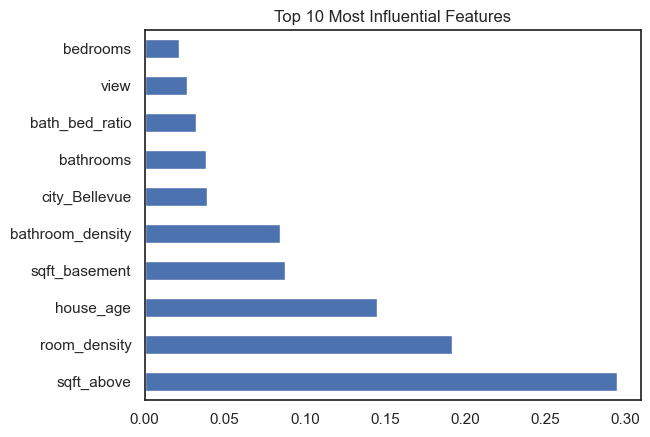

In [31]:
# ==============================
# 18. Interpretability
# ==============================

rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train_scaled, y_train)

importances = pd.Series(rf_temp.feature_importances_, index=X_train_scaled.columns)
importances.nlargest(10).plot(kind="barh")
plt.title("Top 10 Most Influential Features")
plt.show()

 99%|===================| 859/872 [00:25<00:00]        

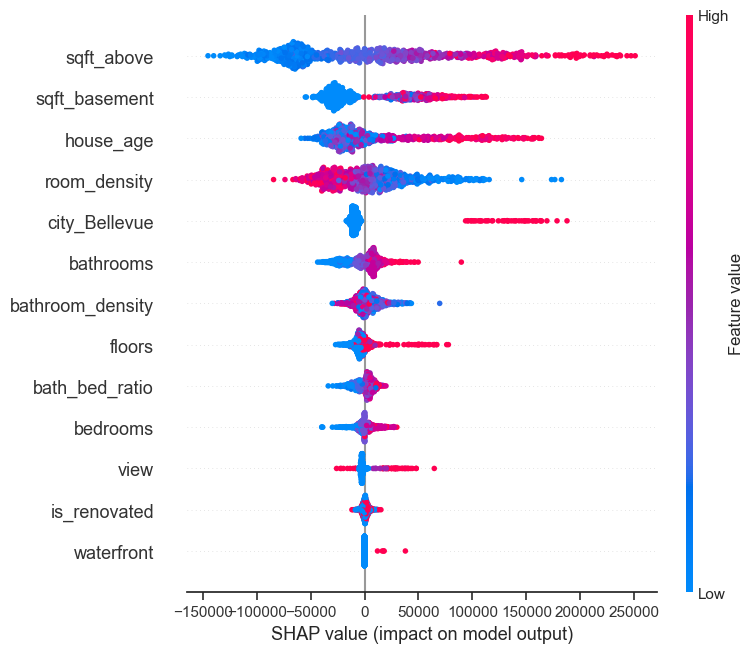

In [32]:
import shap

explainer = shap.Explainer(rf_temp, X_train_scaled)
shap_values = explainer(X_test_scaled, check_additivity=False)

shap.summary_plot(shap_values, X_test_scaled)

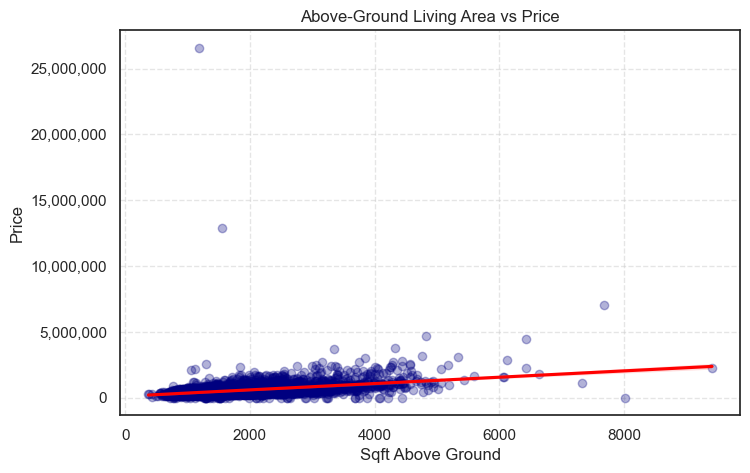

In [33]:
plt.figure(figsize=(8, 5))

sns.regplot(
    x="sqft_above", 
    y="price", 
    data=df,
    scatter_kws={"alpha":0.3, "color":"navy"},
    line_kws={"color":"red"}
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Above-Ground Living Area vs Price")
plt.xlabel("Sqft Above Ground")
plt.ylabel("Price")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

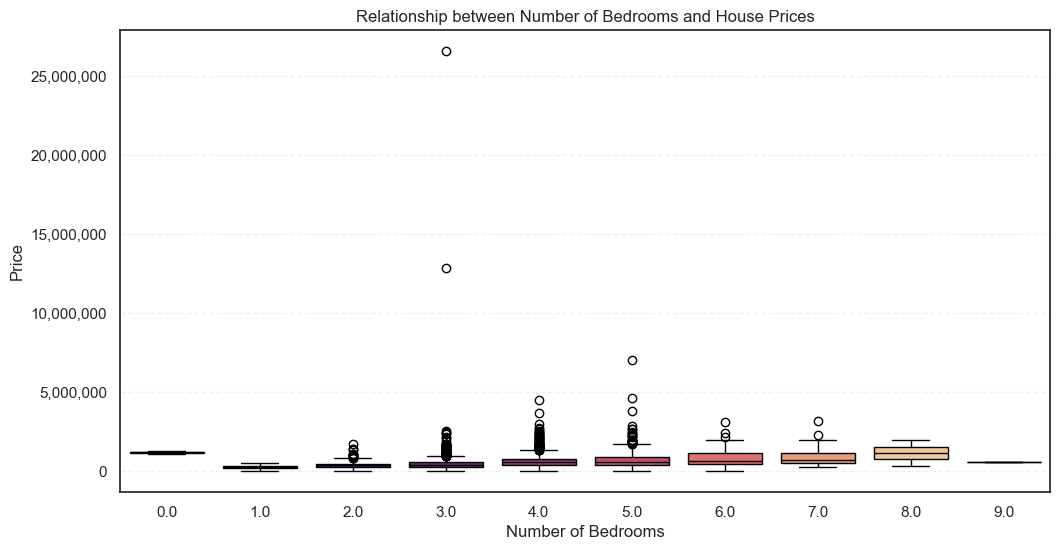

In [34]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    x="bedrooms", 
    y="price", 
    data=df, 
    hue="bedrooms", 
    palette="magma", 
    legend=False
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Relationship between Number of Bedrooms and House Prices")
plt.xlabel("Number of Bedrooms")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()


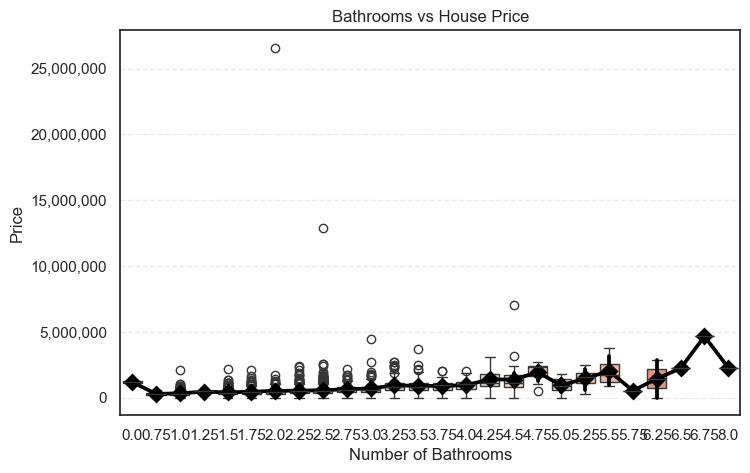

In [35]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    x="bathrooms", 
    y="price", 
    hue="bathrooms",     
    data=df,
    palette="coolwarm",
    legend=False        
)

sns.pointplot(
    x="bathrooms",
    y="price",
    data=df,
    color="black",
    markers="D"
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.title("Bathrooms vs House Price")
plt.xlabel("Number of Bathrooms")
plt.ylabel("Price")
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.show()

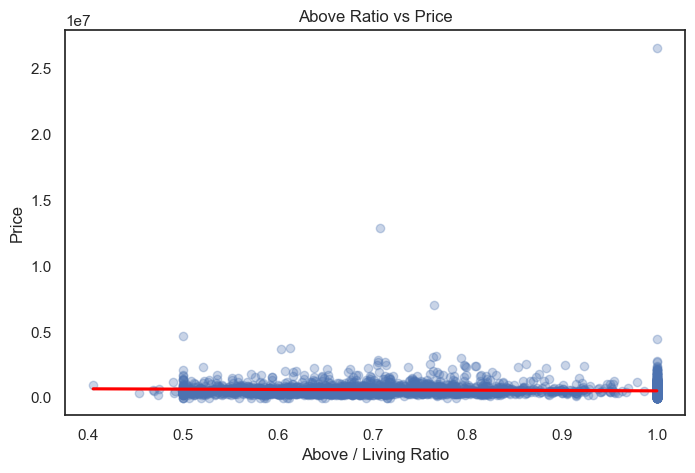

In [36]:
df["above_ratio"] = df["sqft_above"] / df["sqft_living"]

plt.figure(figsize=(8, 5))

sns.regplot(
    x="above_ratio",
    y="price",
    data=df,
    scatter_kws={"alpha":0.3},
    line_kws={"color":"red"}
)

plt.title("Above Ratio vs Price")
plt.xlabel("Above / Living Ratio")
plt.ylabel("Price")

plt.show()


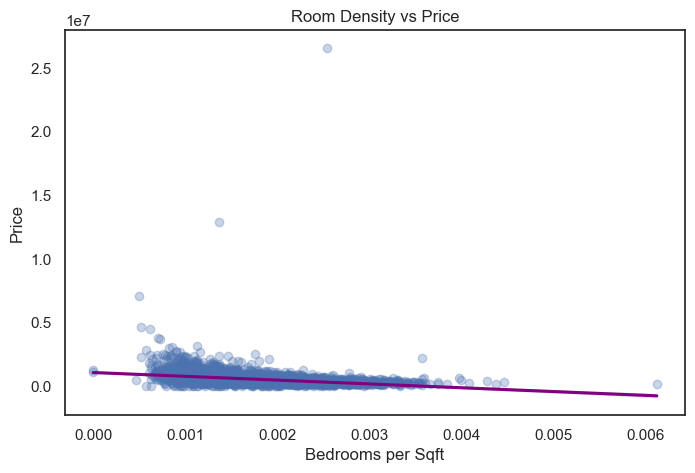

In [37]:
df["room_density"] = df["bedrooms"] / df["sqft_living"]

plt.figure(figsize=(8, 5))

sns.regplot(
    x="room_density",
    y="price",
    data=df,
    scatter_kws={"alpha":0.3},
    line_kws={"color":"purple"}
)

plt.title("Room Density vs Price")
plt.xlabel("Bedrooms per Sqft")
plt.ylabel("Price")

plt.show()


features_to_add = ["above_ratio", "room_density"]

df_model = pd.get_dummies(df, drop_first=True)

X = df_model.drop(columns=["price"])


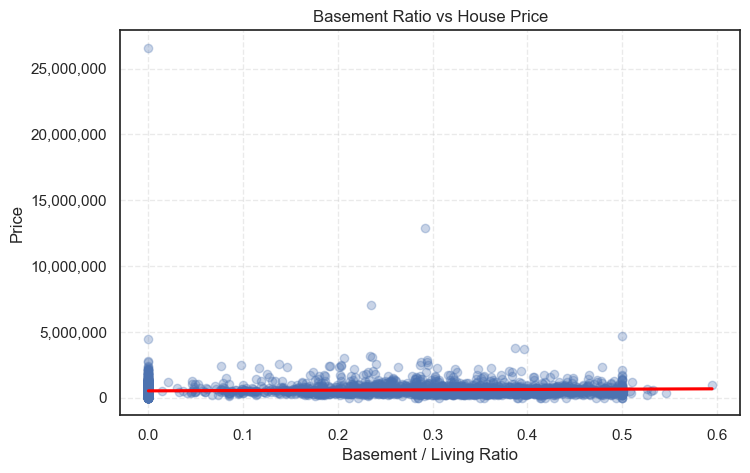

In [38]:
df["basement_ratio"] = df["sqft_basement"] / df["sqft_living"]
plt.figure(figsize=(8, 5))

sns.regplot(
    x="basement_ratio",
    y="price",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Basement Ratio vs House Price")
plt.xlabel("Basement / Living Ratio")
plt.ylabel("Price")

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

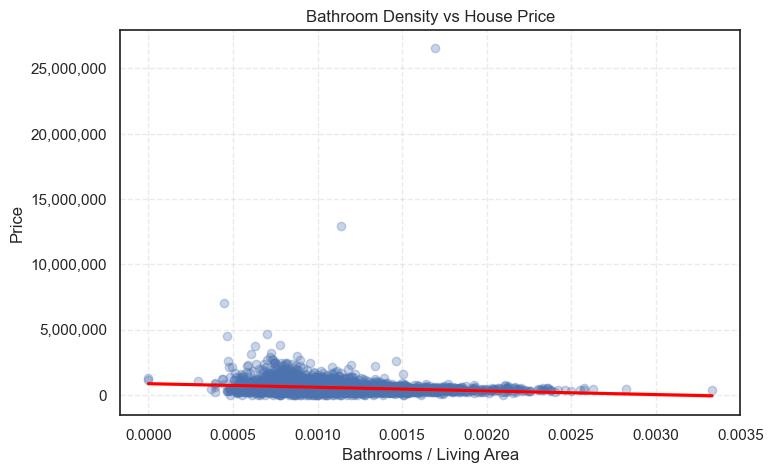

In [39]:
df["bathroom_density"] = df["bathrooms"] / df["sqft_living"]
plt.figure(figsize=(8, 5))

sns.regplot(
    x="bathroom_density",
    y="price",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Bathroom Density vs House Price")
plt.xlabel("Bathrooms / Living Area")
plt.ylabel("Price")

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

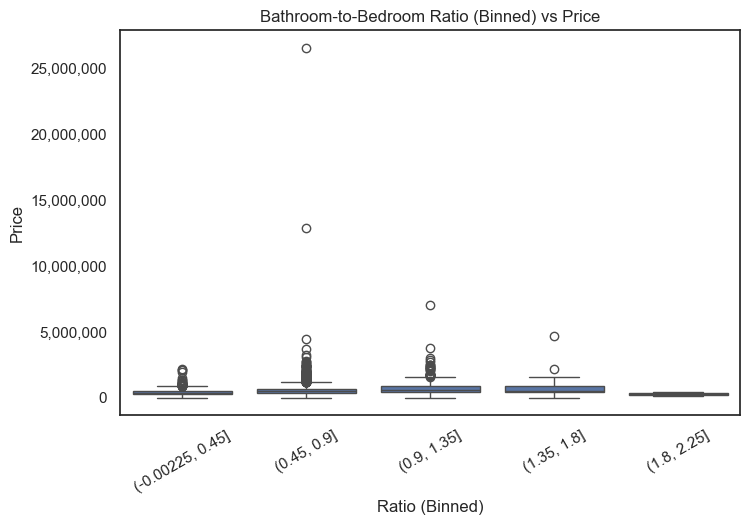

In [40]:
df["bath_bed_ratio"] = df["bathrooms"] / (df["bedrooms"] + 1e-6)
df["bath_bed_bin"] = pd.cut(df["bath_bed_ratio"], bins=5)

plt.figure(figsize=(8, 5))

sns.boxplot(
    x="bath_bed_bin",
    y="price",
    data=df
)

plt.title("Bathroom-to-Bedroom Ratio (Binned) vs Price")
plt.xlabel("Ratio (Binned)")
plt.ylabel("Price")

plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.show()

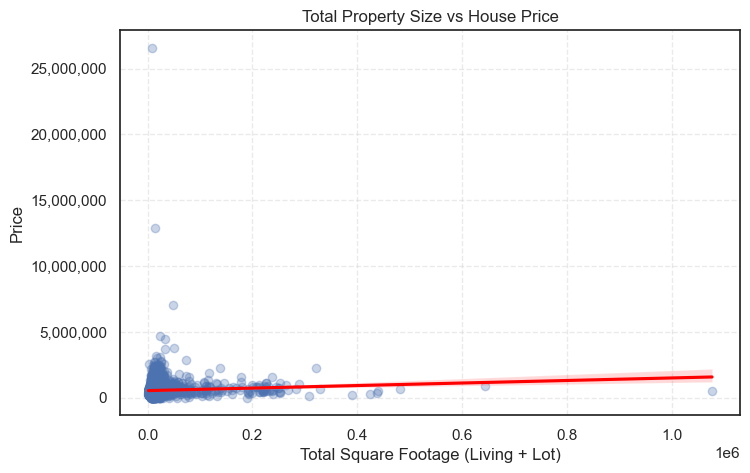

In [41]:
df["total_sqft"] = df["sqft_living"] + df["sqft_lot"]
plt.figure(figsize=(8, 5))

sns.regplot(
    x="total_sqft",
    y="price",
    data=df,
    scatter_kws={"alpha": 0.3},
    line_kws={"color": "red"}
)

plt.title("Total Property Size vs House Price")
plt.xlabel("Total Square Footage (Living + Lot)")
plt.ylabel("Price")

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}'))

plt.grid(True, linestyle='--', alpha=0.4)

plt.show()

### Feature Selection

Some variables such as `street`, `country`, and `date` are removed because:

- `street`: too specific (high cardinality, not generalizable)
- `country`: constant value (no variance, no predictive power)
- `date`: the raw date field does not directly provide meaningful numerical information for the model. Instead, relevant temporal features (e.g., year and month) are extracted from it during feature engineering, making the original date variable redundant.

Removing these features helps simplify the model, reduce noise, and avoid unnecessary redundancy.

In [42]:
cols_to_drop = ["street", "country", "date"]

df_cleaned = df.drop(columns=cols_to_drop, errors="ignore")

print(f"Original features count: {df.shape[1]}")
print(f"Cleaned features count: {df_cleaned.shape[1]}")
print(f"Remaining columns: {df_cleaned.columns.tolist()}")

df_cleaned.head()

Original features count: 25
Cleaned features count: 22
Remaining columns: ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'city', 'statezip', 'above_ratio', 'room_density', 'basement_ratio', 'bathroom_density', 'bath_bed_ratio', 'bath_bed_bin', 'total_sqft']


,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,city,statezip,above_ratio,room_density,basement_ratio,bathroom_density,bath_bed_ratio,bath_bed_bin,total_sqft
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,Shoreline,WA 98133,1.000000,0.002239,0.000000,0.001119,0.500000,"(0.45, 0.9]",9252
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,Seattle,WA 98119,0.923288,0.001370,0.076712,0.000685,0.500000,"(0.45, 0.9]",12700
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,Kent,WA 98042,1.000000,0.001554,0.000000,0.001036,0.666666,"(0.45, 0.9]",13877
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,Bellevue,WA 98008,0.500000,0.001500,0.500000,0.001125,0.750000,"(0.45, 0.9]",10030
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,Redmond,WA 98052,0.587629,0.002062,0.412371,0.001289,0.625000,"(0.45, 0.9]",12440


### Outlier Treatment

The distribution of house prices is highly skewed, with several extreme values (outliers) present in the dataset. These outliers may negatively affect model performance in multiple ways.

First, for linear models such as Linear Regression and Ridge Regression, outliers can disproportionately influence the fitted regression line due to their large magnitude. This can lead to biased parameter estimates and reduced predictive accuracy.

Second, outliers can also impact error-based evaluation metrics such as Root Mean Squared Error (RMSE), which penalises larger errors more heavily. As a result, a small number of extreme values may dominate the overall performance evaluation.

Third, although tree-based models (e.g., Random Forest and XGBoost) are generally more robust to outliers, extreme values can still introduce noise and reduce model stability, particularly when combined with other features.

To address this issue, the Interquartile Range (IQR) method was applied to detect and remove outliers. Observations lying outside the range defined by:

$$
Q1 - 1.5 \times IQR \quad \text{and} \quad Q3 + 1.5 \times IQR
$$

were excluded from the dataset.

This approach helps to reduce the influence of extreme values, improve model stability, and enhance generalisation performance across different models.

A comparison of the price distribution before and after outlier removal confirms that extreme values have been effectively reduced.

Original data size: 4600
After removing outliers: 4360
Number of removed outliers: 240
Percentage removed: 5.22%


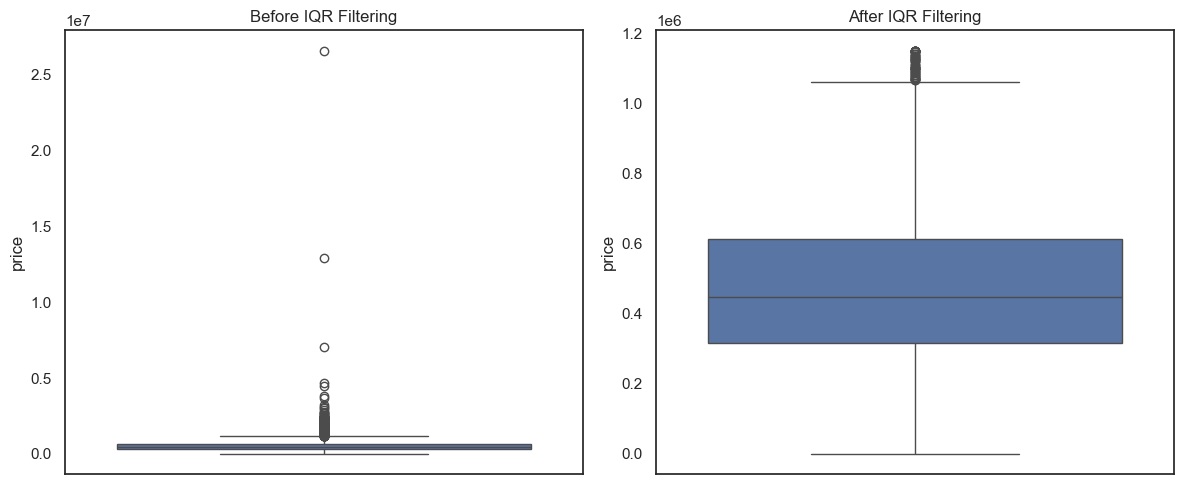

In [43]:
original_shape = df.shape[0]

Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df_cleaned = df[(df["price"] >= lower_bound) & (df["price"] <= upper_bound)].copy()

removed = original_shape - df_cleaned.shape[0]

print(f"Original data size: {original_shape}")
print(f"After removing outliers: {df_cleaned.shape[0]}")
print(f"Number of removed outliers: {removed}")
print(f"Percentage removed: {removed / original_shape * 100:.2f}%")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.boxplot(y=df["price"])
plt.title("Before IQR Filtering")

plt.subplot(1, 2, 2)
sns.boxplot(y=df_cleaned["price"])
plt.title("After IQR Filtering")

plt.tight_layout()
plt.show()

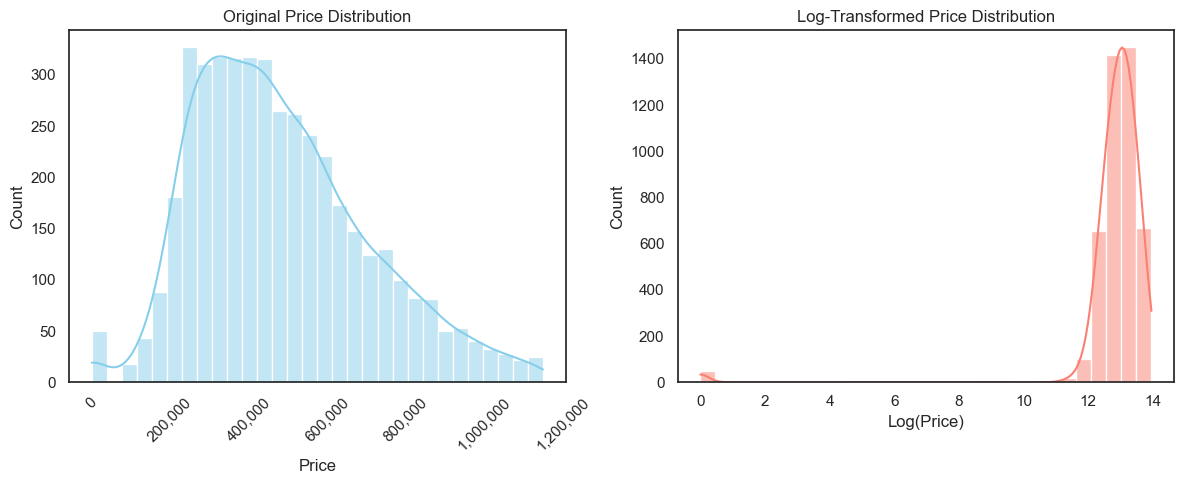

Skewness before: 0.6261498827573944
Skewness after: -7.887665423076715


In [44]:
df_log = df_cleaned.copy()

original_price = df_log["price"].copy()

df_log["log_price"] = np.log1p(df_log["price"])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(original_price, bins=30, kde=True, color='skyblue') 
plt.title("Original Price Distribution")

plt.gca().xaxis.set_major_formatter(StrMethodFormatter('{x:,.0f}')) 
plt.xlabel("Price")
plt.xticks(rotation=45) 

plt.subplot(1,2,2)
sns.histplot(df_log["log_price"], bins=30, kde=True, color='salmon')
plt.title("Log-Transformed Price Distribution")
plt.xlabel("Log(Price)")

plt.tight_layout()
plt.show()
print("Skewness before:", original_price.skew())
print("Skewness after:", df_log["log_price"].skew())

The distribution of house prices is highly right-skewed. 
After applying a log transformation, the distribution becomes more symmetric and closer to a normal distribution.

This transformation reduces skewness and improves the suitability of the data for regression models.

## Feature Engineering

In this section, new features are created to enhance model performance.

- House age is derived from the year built
- A renovation indicator is created
- Seasonal information is extracted from the transaction date

These features aim to capture temporal and structural characteristics that may influence house prices.

In [45]:
df_cleaned["date"] = pd.to_datetime(df_cleaned["date"])

df_cleaned["year"] = df_cleaned["date"].dt.year
df_cleaned["month"] = df_cleaned["date"].dt.month
print(df_cleaned[["year", "month"]].head())

   year  month
0  2014      5
2  2014      5
3  2014      5
4  2014      5
5  2014      5


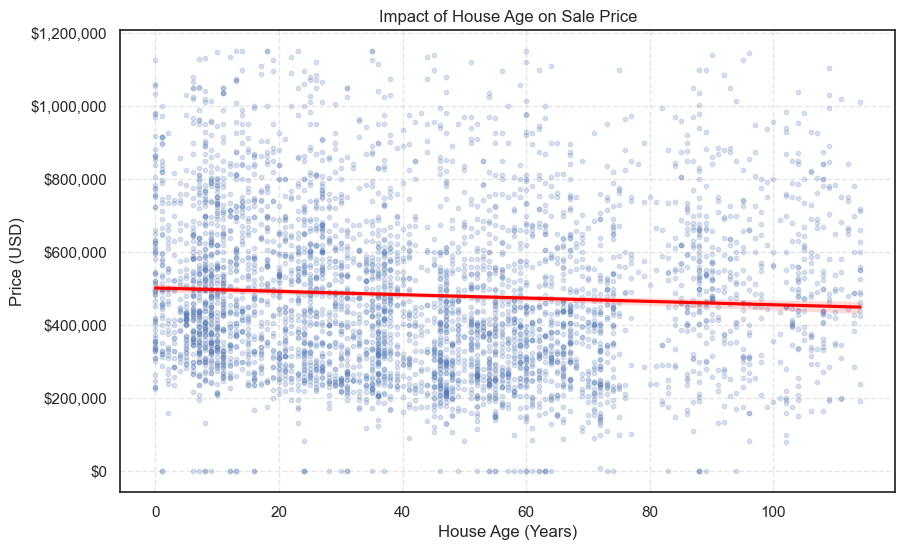

In [46]:
df_cleaned["house_age"] = df_cleaned["year"] - df_cleaned["yr_built"]

# print(df_cleaned[df_cleaned["house_age"] < 0]) 

plt.figure(figsize=(10, 6))

sns.regplot(
    x="house_age",
    y="price",
    data=df_cleaned,
    scatter_kws={'alpha':0.2, 's':10}, 
    line_kws={'color':'red'}          
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Impact of House Age on Sale Price")
plt.xlabel("House Age (Years)")
plt.ylabel("Price (USD)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

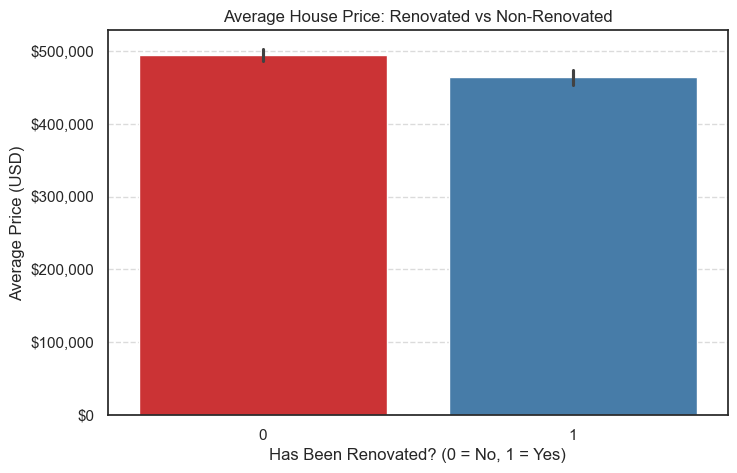

In [47]:
df_cleaned["is_renovated"] = df_cleaned["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)

plt.figure(figsize=(8, 5))

sns.barplot(x="is_renovated", y="price", data=df_cleaned, hue="is_renovated", palette="Set1", legend=False)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Average House Price: Renovated vs Non-Renovated")
plt.xlabel("Has Been Renovated? (0 = No, 1 = Yes)")
plt.ylabel("Average Price (USD)")
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

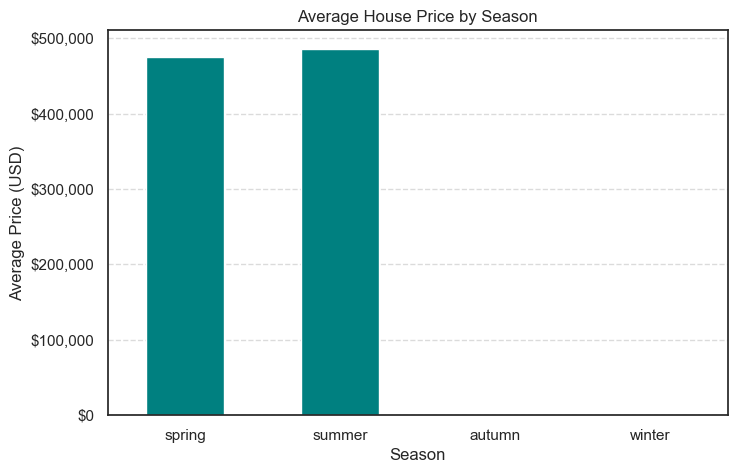

In [48]:
def get_season(month):
    if month in [12, 1, 2]: return "winter"
    elif month in [3, 4, 5]: return "spring"
    elif month in [6, 7, 8]: return "summer"
    else: return "autumn"

df_cleaned["season"] = df_cleaned["month"].apply(get_season)

season_order = ["spring", "summer", "autumn", "winter"]
seasonal_price = df_cleaned.groupby("season")["price"].mean().reindex(season_order)

plt.figure(figsize=(8, 5))
seasonal_price.plot(kind="bar", color='teal')

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Average House Price by Season")
plt.xlabel("Season")
plt.ylabel("Average Price (USD)")
plt.xticks(rotation=0) 
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

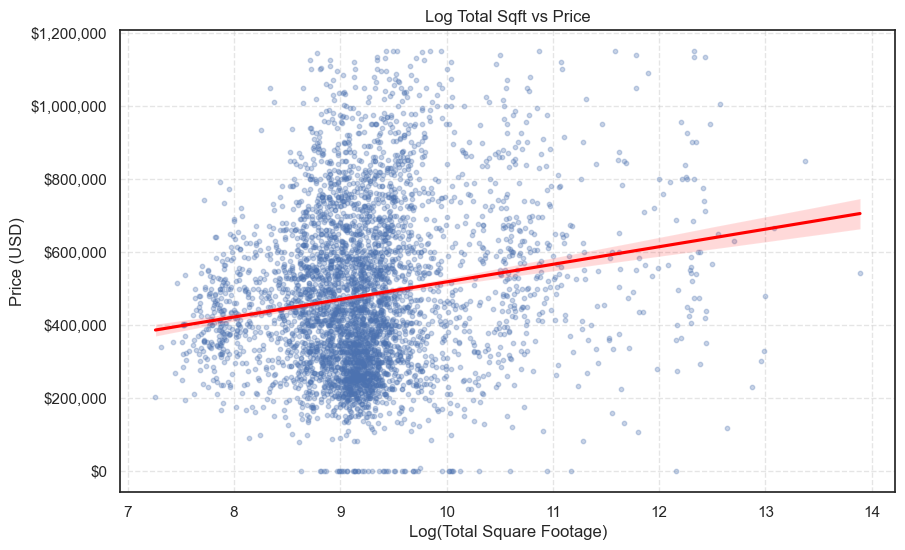

In [49]:
df_cleaned["log_total_sqft"] = np.log1p(df_cleaned["total_sqft"])

plt.figure(figsize=(10, 6))

sns.regplot(
    x="log_total_sqft",
    y="price",
    data=df_cleaned,
    scatter_kws={"alpha":0.3, "s":10},
    line_kws={"color":"red"}
)

plt.title("Log Total Sqft vs Price")
plt.xlabel("Log(Total Square Footage)")
plt.ylabel("Price (USD)")

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

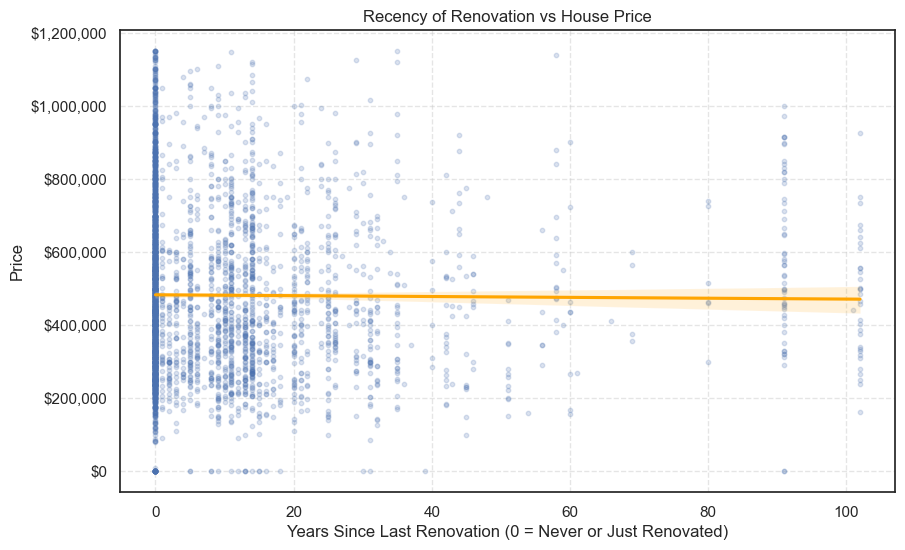

Correlation (Year Since Renovation): -0.0088


In [50]:
df_cleaned["year_since_renovation"] = np.where(
    df_cleaned["yr_renovated"] == 0, 
    0, 
    df_cleaned["year"] - df_cleaned["yr_renovated"]
)

plt.figure(figsize=(10, 6))
sns.regplot(
    x="year_since_renovation",
    y="price",
    data=df_cleaned,
    scatter_kws={"alpha":0.2, "s":10},
    line_kws={"color":"orange"} 
)

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.title("Recency of Renovation vs House Price")
plt.xlabel("Years Since Last Renovation (0 = Never or Just Renovated)")
plt.ylabel("Price")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

print(f"Correlation (Year Since Renovation): {df_cleaned['year_since_renovation'].corr(df_cleaned['price']):.4f}")

In [51]:
# ===== Step 1：Feature Engineering（全部在这里做）=====

# 时间特征
df["date"] = pd.to_datetime(df["date"])
df["year"] = df["date"].dt.year

# 房龄
df["house_age"] = df["year"] - df["yr_built"]

# 翻新
df["is_renovated"] = df["yr_renovated"].apply(lambda x: 0 if x == 0 else 1)

# ratio特征
df["above_ratio"] = df["sqft_above"] / (df["sqft_living"] + 1e-6)
df["room_density"] = df["bedrooms"] / (df["sqft_living"] + 1e-6)
df["basement_ratio"] = df["sqft_basement"] / (df["sqft_living"] + 1e-6)
df["bathroom_density"] = df["bathrooms"] / (df["sqft_living"] + 1e-6)
df["bath_bed_ratio"] = df["bathrooms"] / (df["bedrooms"] + 1e-6)
df["total_sqft"] = df["sqft_living"] + df["sqft_lot"]

# ===== Step 2：Cleaning =====
df_cleaned = df.drop(columns=['street', 'country', 'date'], errors='ignore')

# ===== Step 3：Encoding =====
df_model = pd.get_dummies(df_cleaned, drop_first=True)

# ===== Step 4：Correlation =====
corr = df_model.corr(numeric_only=True)
corr_price = corr["price"].abs().sort_values(ascending=False)

# ===== Step 5：Feature selection =====
selected_features = [
    f for f in corr_price.index
    if f != "price" and corr_price[f] > 0.2
]

# ⭐ 手动补充（关键）
important_features = ["waterfront", "view", "is_renovated", "house_age"]

selected_features = list(set(selected_features + important_features))

print("Final selected features:")
print(selected_features)

# ===== Step 6：检查 =====
for f in important_features:
    print(f"{f}:", corr_price[f] if f in corr_price else "Not found")

Final selected features:
['house_age', 'sqft_above', 'room_density', 'is_renovated', 'sqft_basement', 'view', 'bedrooms', 'waterfront', 'sqft_living', 'bathrooms']
waterfront: 0.13564832245848626
view: 0.22850417280567392
is_renovated: 0.02859474916510143
house_age: 0.02185683039547893


In [52]:
corr_selected = df_model[selected_features].corr().abs()

upper = corr_selected.where(np.triu(np.ones(corr_selected.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.8)]

print("Highly correlated features to drop:", to_drop)

final_features = [f for f in selected_features if f not in to_drop]
print("Final selected features:")
print(final_features)

Highly correlated features to drop: ['sqft_living']
Final selected features:
['house_age', 'sqft_above', 'room_density', 'is_renovated', 'sqft_basement', 'view', 'bedrooms', 'waterfront', 'bathrooms']


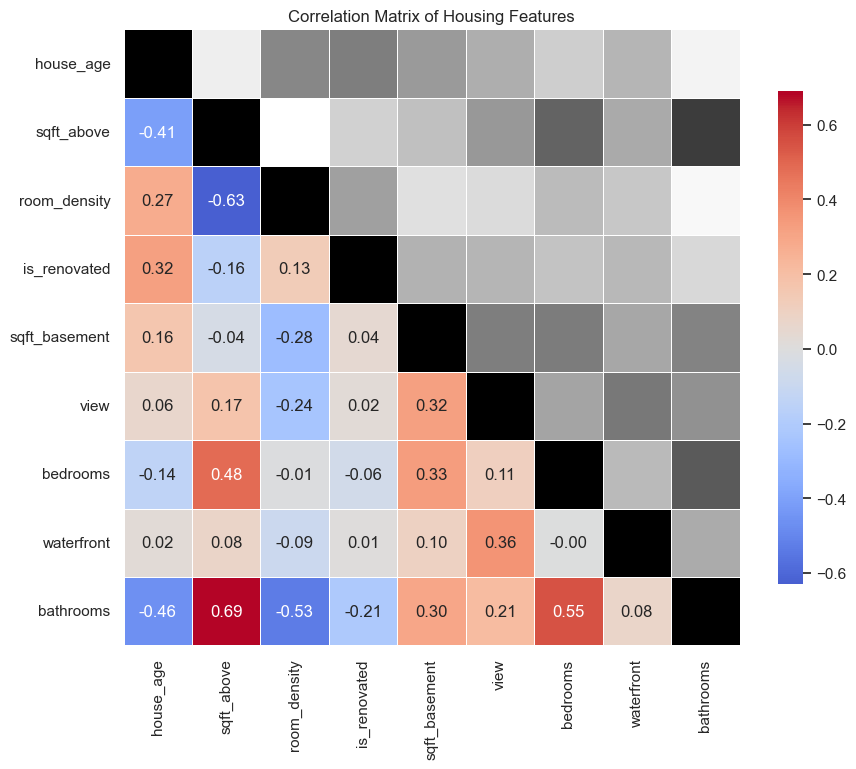

In [53]:
corr_matrix = df_model[final_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr_matrix,
    cmap="Greys",      
    cbar=False,
    square=True
)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Matrix of Housing Features")
plt.show()

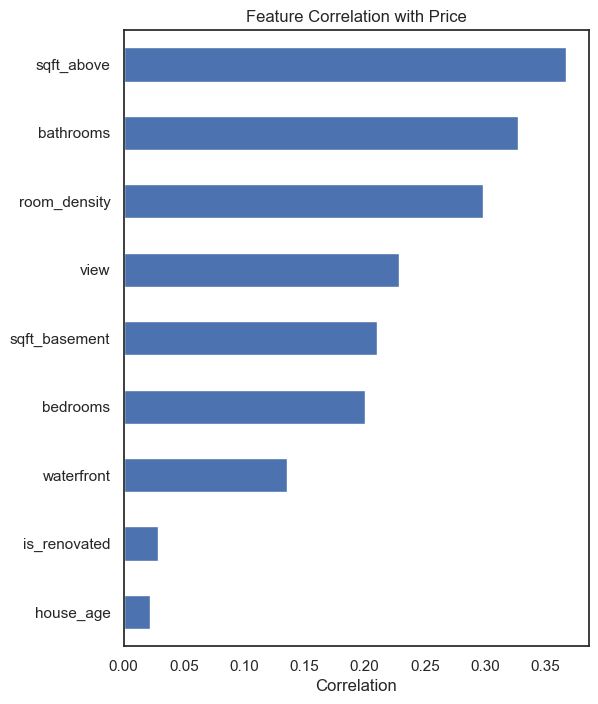

In [54]:
plt.figure(figsize=(6, 8))

corr_price[final_features].sort_values().plot(kind="barh")

plt.title("Feature Correlation with Price")
plt.xlabel("Correlation")
plt.show()

### Train-Test Split

The dataset was divided into training and testing sets using an 80/20 split. 
The training set is used to train the models, while the test set is used 
to evaluate their performance on unseen data.

A fixed random seed (random_state=42) is used to ensure reproducibility.

In [55]:
df_model = df_cleaned.copy()
df_model = df_model.drop(columns=['street', 'country', 'date'], errors='ignore')
df_model = pd.get_dummies(df_model, drop_first=True)

# Split features and target
X = df_model.drop(columns=["price", "log_price"], errors="ignore")
y = df_model["price"]

# Train-test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 80% train, 20% test
    random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (3680, 144)
Test size: (920, 144)


In [56]:
irrelevant_strings = ['street', 'country', 'date']

# 2. drop
df_model = df_model.drop(columns=irrelevant_strings, errors='ignore')

# 3. int (0/1)
df_model = df_model.apply(lambda x: x.astype(int) if x.dtype == 'bool' else x)

X = df_model.drop(columns=["price", "log_price"], errors="ignore")
y = df_model["price"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Remaining features:", X_train.columns.tolist())
print("Non-numeric count:", X_train.select_dtypes(exclude=[np.number]).shape[1])

Remaining features: ['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'above_ratio', 'room_density', 'basement_ratio', 'bathroom_density', 'bath_bed_ratio', 'total_sqft', 'year', 'house_age', 'is_renovated', 'city_Auburn', 'city_Beaux Arts Village', 'city_Bellevue', 'city_Black Diamond', 'city_Bothell', 'city_Burien', 'city_Carnation', 'city_Clyde Hill', 'city_Covington', 'city_Des Moines', 'city_Duvall', 'city_Enumclaw', 'city_Fall City', 'city_Federal Way', 'city_Inglewood-Finn Hill', 'city_Issaquah', 'city_Kenmore', 'city_Kent', 'city_Kirkland', 'city_Lake Forest Park', 'city_Maple Valley', 'city_Medina', 'city_Mercer Island', 'city_Milton', 'city_Newcastle', 'city_Normandy Park', 'city_North Bend', 'city_Pacific', 'city_Preston', 'city_Ravensdale', 'city_Redmond', 'city_Renton', 'city_Sammamish', 'city_SeaTac', 'city_Seattle', 'city_Shoreline', 'city_Skykomish', 'city_Snoqualm

### Model Evaluation

Four models were evaluated: Linear Regression, Random Forest, XGBoost, and MLP.

In [57]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

In [58]:
# Hyperparameter Tunin
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid_refined = {
    "n_estimators": [80, 100, 120, 150],
    "learning_rate": [0.03, 0.05, 0.08, 0.1],
    "max_depth": [4, 5, 6],
    "min_child_weight": [1, 3, 5],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0]
}

xgb_refined = XGBRegressor(
    objective="reg:squarederror",
    random_state=42
)

grid_refined = GridSearchCV(
    estimator=xgb_refined,
    param_grid=param_grid_refined,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    verbose=1
)

grid_refined.fit(X_train, y_train)

best_xgb_refined = grid_refined.best_estimator_

print("Best refined params:", grid_refined.best_params_)
print("Best refined CV RMSE:", -grid_refined.best_score_)

best_xgb = grid_refined.best_estimator_

Fitting 5 folds for each of 1296 candidates, totalling 6480 fits


ValueError: 
All the 6480 fits failed.
It is very likely that your model is misconfigured.
You can try to debug the error by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
6480 fits failed with the following error:
Traceback (most recent call last):
  File "/opt/anaconda3/lib/python3.13/site-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/opt/anaconda3/lib/python3.13/site-packages/xgboost/core.py", line 751, in inner_f
    return func(**kwargs)
  File "/opt/anaconda3/lib/python3.13/site-packages/xgboost/sklearn.py", line 1343, in fit
    train_dmatrix, evals = _wrap_evaluation_matrices(
                           ~~~~~~~~~~~~~~~~~~~~~~~~~^
        missing=self.missing,
        ^^^^^^^^^^^^^^^^^^^^^
    ...<14 lines>...
        feature_types=fea

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.base import clone

# 5-Fold Out-of-Fold
# Level 1 - base model
base_models = {
    "Linear": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42),
    "XGBoost": best_xgb,
    #"MLP": MLPRegressor(hidden_layer_sizes=(100,50), max_iter=2000, alpha=0.001, random_state=42)
    "MLP": MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=2000, alpha=0.001, learning_rate_init=0.001, early_stopping=True, n_iter_no_change=20, random_state=42)
}

results = []

for name, model in base_models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append([name, rmse, r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])

print("\n=== Base Model Performance ===")
print(results_df)

# initial
train_oof = np.zeros((X_train.shape[0], len(base_models)))
test_preds = np.zeros((X_test.shape[0], len(base_models)))

# set 5-Fold
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# train
for i, (name, model) in enumerate(base_models.items()):
    print(f"Generating OOF for {name}...")
    
    fold_test_preds = np.zeros((X_test.shape[0], 5))
    
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
        
        model_clone = clone(model) 
        
        X_f_train, X_f_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_f_train, y_f_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        model_clone.fit(X_f_train, y_f_train)
        
        train_oof[val_idx, i] = model_clone.predict(X_f_val)
        fold_test_preds[:, fold] = model_clone.predict(X_test)
    
    test_preds[:, i] = fold_test_preds.mean(axis=1)

In [ ]:
from sklearn.linear_model import Ridge

# Step 1: meta-features
X_meta_train = pd.DataFrame(train_oof, columns=base_models.keys())
X_meta_test = pd.DataFrame(test_preds, columns=base_models.keys())

# Step 2: Passthrough
X_meta_train_full = pd.concat(
    [X_meta_train.reset_index(drop=True), X_train.reset_index(drop=True)],
    axis=1
)

X_meta_test_full = pd.concat(
    [X_meta_test.reset_index(drop=True), X_test.reset_index(drop=True)],
    axis=1
)

# Step 3: Meta-learner（Ridge）
meta_learner = Ridge(alpha=1.0)
meta_learner.fit(X_meta_train_full, y_train)

# Step 4: predict
y_final_pred = meta_learner.predict(X_meta_test_full)

print("Level 2 (Passthrough + Ridge): training successful.")

print("Meta-features (first 5 rows):")
print(X_meta_train_full.head())

final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_r2 = r2_score(y_test, y_final_pred)

print("\n=== Final Stacking Performance ===")
print(f"RMSE: {final_rmse:.2f}")
print(f"R2: {final_r2:.4f}")

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from IPython.display import display, Markdown

final_rmse = np.sqrt(mean_squared_error(y_test, y_final_pred))
final_r2 = r2_score(y_test, y_final_pred)

display(Markdown("---"))
display(Markdown("#### **Stacking Ensemble Evaluation Results**"))

results_df = pd.DataFrame({
    "Metric": ["Root Mean Squared Error (RMSE)", "R-squared Score ($R^2$)"],
    "Score": [f"${final_rmse:,.2f}", f"{final_r2:.4f}"]
})

display(results_df)

display(Markdown(f"""
> **Discussion:**
> The final model achieved an $R^2$ of **{final_r2:.4f}**. This indicates that our ensemble can explain approximately **{final_r2*100:.1f}%** of the variance in house prices. 
> Compared to the base models, the stacking approach effectively reduced the RMSE by leveraging the strengths of different algorithmic paradigms.
"""))

In [ ]:
!pip install shap

rf_temp = RandomForestRegressor(n_estimators=100, random_state=42)
rf_temp.fit(X_train, y_train)

import shap

# explainer
explainer = shap.Explainer(rf_temp, X_train)

# SHAP values（test set）
shap_values = explainer(X_test, check_additivity=False)

# Summary plot
shap.summary_plot(shap_values, X_test)

importances = pd.Series(rf_temp.feature_importances_, index=X_train.columns)
importances.nlargest(10).plot(kind='barh')
plt.title("Top 10 Most Influential Features")
plt.show()

In [ ]:
for name, model in base_models.items():
    print(f"Running CV for {name}...")
    
    try:
        scores = cross_val_score(
            model,
            X_train,
            y_train,
            cv=5,
            scoring="neg_root_mean_squared_error"
        )
        print(f"{name} CV RMSE:", -scores.mean())
    
    except Exception as e:
        print(f"{name} FAILED:", e)

In [ ]:
results.append(["Stacking", final_rmse, final_r2])

results_df = pd.DataFrame(results, columns=["Model", "RMSE", "R2"])

print(results_df.sort_values(by="RMSE"))

In [ ]:
print("\n=== Ablation Study (Remove One Model) ===")

from sklearn.base import clone
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold

ablation_results = []

model_names = list(base_models.keys())

for remove_model in model_names:
    
    print(f"\n--- Removing {remove_model} ---")
    
    # remove one
    ab_models = {k: v for k, v in base_models.items() if k != remove_model}
    
    # initialize
    train_oof_ab = np.zeros((X_train.shape[0], len(ab_models)))
    test_preds_ab = np.zeros((X_test.shape[0], len(ab_models)))
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    # OOF
    for i, (name, model) in enumerate(ab_models.items()):
        
        fold_test_preds = np.zeros((X_test.shape[0], 5))
        
        for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_train)):
            model_clone = clone(model)
            
            X_f_train, X_f_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
            y_f_train, y_f_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            
            model_clone.fit(X_f_train, y_f_train)
            
            train_oof_ab[val_idx, i] = model_clone.predict(X_f_val)
            fold_test_preds[:, fold] = model_clone.predict(X_test)
        
        test_preds_ab[:, i] = fold_test_preds.mean(axis=1)
    
    # meta features
    X_meta_train_ab = pd.DataFrame(train_oof_ab, columns=ab_models.keys())
    X_meta_test_ab = pd.DataFrame(test_preds_ab, columns=ab_models.keys())
    
    X_meta_train_ab_full = pd.concat(
        [X_meta_train_ab.reset_index(drop=True), X_train.reset_index(drop=True)],
        axis=1
    )
    X_meta_test_ab_full = pd.concat(
        [X_meta_test_ab.reset_index(drop=True), X_test.reset_index(drop=True)],
        axis=1
    )
    
    # meta learner
    meta_ab = Ridge(alpha=1.0)
    meta_ab.fit(X_meta_train_ab_full, y_train)
    
    y_pred_ab = meta_ab.predict(X_meta_test_ab_full)
    
    rmse_ab = np.sqrt(mean_squared_error(y_test, y_pred_ab))
    r2_ab = r2_score(y_test, y_pred_ab)
    
    print(f"RMSE: {rmse_ab:.2f}")
    print(f"R2: {r2_ab:.4f}")
    
    ablation_results.append([f"Remove {remove_model}", rmse_ab, r2_ab])


ablation_results.append(["Full Stacking", final_rmse, final_r2])

ablation_df = pd.DataFrame(ablation_results, columns=["Experiment", "RMSE", "R2"])

print("\n=== Ablation Summary ===")
print(ablation_df.sort_values(by="RMSE"))